# Explainable Commodity Prices

Every result in this notebook comes from a **rolling walk-forward** protocol.
Nothing is trained on the full sample. On each window we retrain the
autoencoder, refit the macro canonical-correlation (CCA) basis, and forecast the
next block, then advance. The two questions, asked jointly on every window:

1. **Does the macro *explanation* of the commodity factor space survive** when
   the representation is re-fit and allowed to drift regime to regime?
2. **Does the factor state *forecast* returns** out-of-sample at any horizon once
   it, too, is re-estimated every window?

| Stage | Command | Output |
|-------|---------|--------|
| Overall panel (rolling AE+CCA+forecast) | `make rolling` / `rolling-beta` | `results/rolling_forecast[_beta]/` |
| Sector decomposition (rolling, per sector) | `make rolling-sectors` / `-beta` | `results/rolling_sectors[_beta]/` |

**Panel:** 21 daily commodity futures. **Macro:** 37 stationary variables.
**Overall factors:** K=5; **per-sector:** K≤3. **Window:** 252d train / 21d test /
21d step (~125 non-overlapping OOS blocks). **Seed:** 0.


## 0. Setup

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

# Graded-stability palette (matches the pipeline reports) and sector palette.
CLASS_C = {"stable": "#2A6F97", "partial": "#E9A23B", "weak": "#B0B0B0", "rotating": "#B0B0B0"}
BLOCK_C = {"overall": "#2A6F97", "energy": "#DD8452", "agriculture": "#55A868", "metals": "#8172B3"}
BLOCK_ORDER = ["overall", "energy", "agriculture", "metals"]
NULL_C, BAR_C = "#333333", "#C44E52"

# Resolve project root so `eqcp` is importable and result paths resolve.
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = Path(__file__).resolve().parent if "__file__" in dir() else ROOT
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook with the working directory set to the project root.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Uncomment to regenerate every artifact this notebook reads (~4-5 min total):
# import subprocess
# subprocess.run("make rolling-all", shell=True, check=True, cwd=ROOT)

# Each chart is saved as its OWN png under figures/notebook/ so it can be dropped
# into a slide individually.
NB_FIG_DIR = ROOT / "figures" / "notebook"
NB_FIG_DIR.mkdir(parents=True, exist_ok=True)

def show_save(fig, name: str) -> None:
    path = NB_FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"saved -> {path.relative_to(ROOT)}")

def load(rel: str) -> pd.DataFrame:
    return pd.read_csv(ROOT / rel)

OV = "results/rolling_forecast"          # overall, vanilla AE
OVB = "results/rolling_forecast_beta"    # overall, beta-VAE
SEC = "results/rolling_sectors"          # per-sector, vanilla AE
SECB = "results/rolling_sectors_beta"    # per-sector, beta-VAE
print("Reading rolling artifacts from:", OV, "|", SEC)


Reading rolling artifacts from: results/rolling_forecast | results/rolling_sectors


## 1. The rolling protocol

For each window it calculates:

- z-scores returns on **train-window statistics only**, retrains the AE on the
  252-day train block, and encodes train+test days through the just-trained
  encoder;
- refits the CCA basis on the **train block only**, orders canonical dims by
  train canonical correlation, and sign-anchors each on its dominant macro
  loading so ranks are comparable window to window;
- fits a direct h-step factor-augmented AR on the train block and forecasts the
  held-out 21-day test block; then advances one non-overlapping block.

The AE latent axes rotate window to window (gauge + optimizer multiplicity +
regime drift), so the *factor side* is not comparable across windows. The
**macro side is** — every window's canonical vectors live in the same fixed
37-series macro space — which is exactly what makes the explainability question
answerable under rolling.


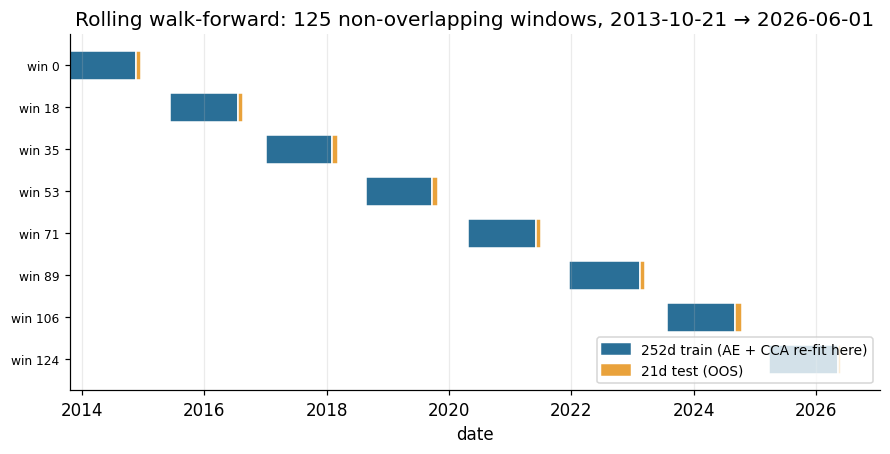

saved -> figures/notebook/rolling_protocol.png
125 windows | 252d train / 21d test / 21d step | AE + CCA basis re-fit on every window (nothing fit on the full sample).


In [2]:
# Schematic: the walk-forward windows, drawn from the actual roll calendar.
wins = load(f"{OV}/rolling_windows.csv")
n_win = len(wins)
span = (wins["train_start"].iloc[0], wins["test_end"].iloc[-1])

fig, ax = plt.subplots(figsize=(9.5, 4.2))
show_idx = np.linspace(0, n_win - 1, 8).round().astype(int)
for row, w in enumerate(show_idx):
    ts = pd.Timestamp(wins["train_start"].iloc[w])
    te = pd.Timestamp(wins["test_start"].iloc[w])
    tend = pd.Timestamp(wins["test_end"].iloc[w])
    ax.barh(row, (te - ts).days, left=ts, color="#2A6F97", edgecolor="white", height=0.7)
    ax.barh(row, (tend - te).days, left=te, color="#E9A23B", edgecolor="white", height=0.7)
ax.set_yticks(range(len(show_idx)))
ax.set_yticklabels([f"win {w}" for w in show_idx], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("date")
ax.grid(axis="y", alpha=0)
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="#2A6F97"),
    plt.Rectangle((0, 0), 1, 1, color="#E9A23B"),
], labels=["252d train (AE + CCA re-fit here)", "21d test (OOS)"], loc="lower right", fontsize=9)
ax.set_title(f"Rolling walk-forward: {n_win} non-overlapping windows, {span[0]} → {span[1]}")
show_save(fig, "rolling_protocol")

print(f"{n_win} windows | 252d train / 21d test / 21d step | "
      f"AE + CCA basis re-fit on every window (nothing fit on the full sample).")


## 2. Does the macro explanation survive rolling? (overall panel)

For each canonical rank we take its 37-dim macro structure-correlation vector in
every window (comparable across windows because the macro series never change)
and measure the **cross-window median |cosine|** — does rank *k* keep pointing at
the same macro combination as the AE rotates? Benchmarked three ways:

- **Label-shuffle null** — permuting each window's macro labels destroys
  cross-window identity (random |cos| ≈ 0.13); we report a one-sided `p_value`.
- **Out-of-sample check** — `median_rho_oos` is the frozen-in-window canonical
  correlation on the *held-out* test block, so the axis must hold up beyond fit.
- **Graded ladder** — `stable` (clears the 0.7 bar *and* the null) → `partial` →
  `weak` → `rotating`.


1 of 5 canonical axes keep a regime-transportable macro identity (class = stable).



,rank,median_abs_cos,null_p95,chance_abs_cos,p_value,median_rho_oos,frac_windows_rho_oos_ge_0.3,stability_class
0,V1,0.820,0.115,0.131,0.005,0.534,0.832,stable
1,V2,0.605,0.117,0.131,0.005,0.317,0.528,partial
2,V3,0.280,0.122,0.131,0.005,0.200,0.280,weak
3,V4,0.214,0.119,0.131,0.005,0.185,0.296,weak
4,V5,0.191,0.117,0.131,0.005,0.171,0.224,weak


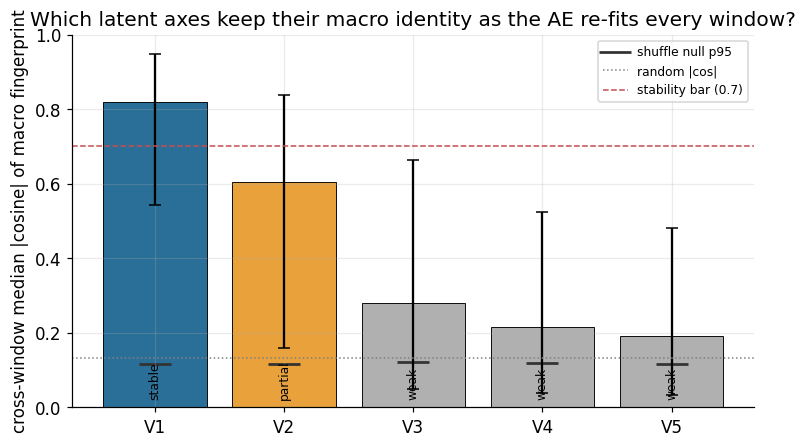

saved -> figures/notebook/overall_macro_stability.png


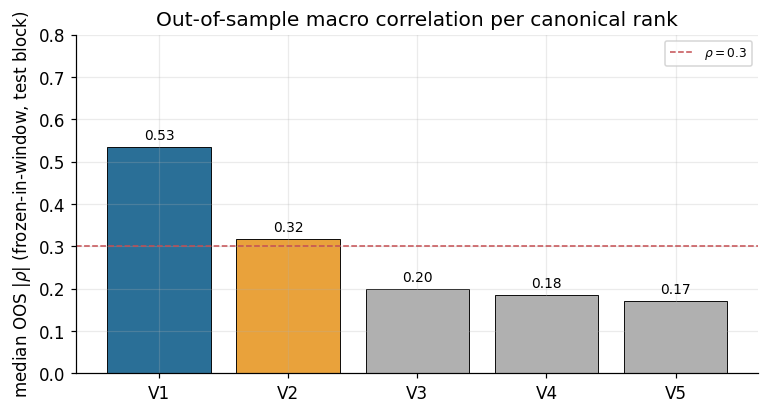

saved -> figures/notebook/overall_oos_rho.png


In [3]:
stab = load(f"{OV}/rank_stability.csv")
K = len(stab)
n_stable = int(stab["macro_stable"].sum())
show = ["rank", "median_abs_cos", "null_p95", "chance_abs_cos", "p_value",
        "median_rho_oos", "frac_windows_rho_oos_ge_0.3", "stability_class"]
print(f"{n_stable} of {K} canonical axes keep a regime-transportable macro identity "
      f"(class = stable).\n")
display(stab[show].round(3))

# Chart A: cross-window macro-fingerprint cosine per rank, vs the shuffle null.
fig, ax = plt.subplots(figsize=(8, 4.4))
x = np.arange(K)
colors = [CLASS_C.get(c, "#B0B0B0") for c in stab["stability_class"]]
lo = stab["median_abs_cos"] - stab["q10_abs_cos"]
hi = stab["q90_abs_cos"] - stab["median_abs_cos"]
ax.bar(x, stab["median_abs_cos"], yerr=[lo, hi], capsize=4, color=colors,
       edgecolor="black", lw=0.6)
ax.scatter(x, stab["null_p95"], marker="_", s=420, color=NULL_C, lw=1.8, label="shuffle null p95")
ax.axhline(stab["chance_abs_cos"].iloc[0], color="grey", ls=":", lw=1, label="random |cos|")
ax.axhline(0.7, color=BAR_C, ls="--", lw=1, label="stability bar (0.7)")
for xi, c in zip(x, stab["stability_class"]):
    ax.annotate(c, (xi, 0.02), ha="center", va="bottom", fontsize=8, rotation=90, color="black")
ax.set_xticks(x); ax.set_xticklabels(stab["rank"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("cross-window median |cosine| of macro fingerprint")
ax.set_title("Which latent axes keep their macro identity as the AE re-fits every window?")
ax.legend(fontsize=8)
show_save(fig, "overall_macro_stability")

# Chart B: does each axis still track macro OUT-OF-SAMPLE (held-out test blocks)?
fig, ax = plt.subplots(figsize=(8, 4.0))
ax.bar(x, stab["median_rho_oos"], color=colors, edgecolor="black", lw=0.6)
ax.axhline(0.3, color=BAR_C, ls="--", lw=1, label=r"$\rho=0.3$")
for xi, r in zip(x, stab["median_rho_oos"]):
    ax.annotate(f"{r:.2f}", (xi, r + 0.01), ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(stab["rank"])
ax.set_ylim(0, 0.8)
ax.set_ylabel(r"median OOS $|\rho|$ (frozen-in-window, test block)")
ax.set_title("Out-of-sample macro correlation per canonical rank")
ax.legend(fontsize=8)
show_save(fig, "overall_oos_rho")


In [4]:
# What macro combination does each surviving axis point at (mean across windows)?
fp = load(f"{OV}/macro_fingerprint.csv").set_index(load(f"{OV}/macro_fingerprint.csv").columns[0])
rows = []
for _, r in stab.iterrows():
    col = r["rank"]
    top = fp[col].abs().sort_values(ascending=False).head(4).index
    rows.append({"rank": col, "class": r["stability_class"],
                 "top macro drivers (mean across windows)":
                 "; ".join(f"{n}({fp.loc[n, col]:+.2f})" for n in top)})
print("Regime-averaged macro fingerprint per rank:")
display(pd.DataFrame(rows))

lead = stab.iloc[0]
print(
    f"Leading axis {lead['rank']}: cross-window |cos|={lead['median_abs_cos']:.2f} "
    f"(random {lead['chance_abs_cos']:.2f}, p={lead['p_value']:.3f}); "
    f"OOS |rho|={lead['median_rho_oos']:.2f}, clearing 0.3 in "
    f"{lead['frac_windows_rho_oos_ge_0.3']:.0%} of windows -> a dollar/inflation/energy-equity "
    f"axis that is transportable across regimes even though the AE latent space rotates freely."
)


Regime-averaged macro fingerprint per rank:


,rank,class,top macro drivers (mean across windows)
0,V1,stable,xle(+0.32); inflsw_5y(+0.23); be_5y(+0.23); fx...
1,V2,partial,fx_usdclp(+0.20); fx_usdzar(+0.15); xle(+0.14)...
2,V3,weak,ust_10y(+0.08); ust_5y(+0.08); tips_10y(+0.07)...
3,V4,weak,fx_usdbrl(+0.10); fx_usdzar(+0.07); fx_bbdxy(+...
4,V5,weak,fx_usdbrl(+0.07); fx_usdcad(+0.06); fx_usdnok(...


Leading axis V1: cross-window |cos|=0.82 (random 0.13, p=0.005); OOS |rho|=0.53, clearing 0.3 in 83% of windows -> a dollar/inflation/energy-equity axis that is transportable across regimes even though the AE latent space rotates freely.


## 3. Sector decomposition under rolling

The identical rolling engine, run independently on each commodity sector (its own
AE, K≤3, re-fit every window). The question: **which sectors keep a stable,
out-of-sample macro axis under full per-window re-fitting, and which rotate?**


,block,n_commodities,n_factors,n_stable_ranks,lead_rank_class,lead_median_abs_cos,lead_median_rho_oos,best_forecast_cw_p
0,overall,21,5,1,stable,0.820,0.534,0.404
1,energy,5,3,1,stable,0.778,0.441,0.130
2,agriculture,9,3,0,weak,0.381,0.178,0.381
3,metals,7,3,1,stable,0.845,0.441,0.109


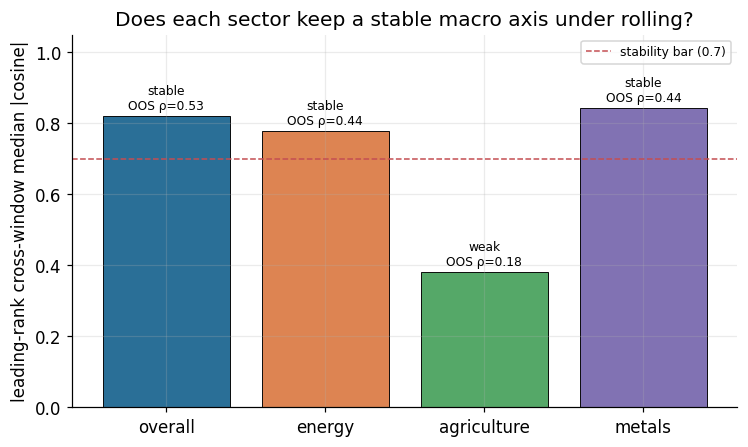

saved -> figures/notebook/sector_leading_axis.png


In [5]:
summ = load(f"{SEC}/sector_summary.csv")
order = [b for b in BLOCK_ORDER if b in summ["block"].tolist()]
summ = summ.set_index("block").reindex(order).reset_index()
display(summ[["block", "n_commodities", "n_factors", "n_stable_ranks", "lead_rank_class",
              "lead_median_abs_cos", "lead_median_rho_oos", "best_forecast_cw_p"]].round(3))

# Leading-axis stability by block: the sector headline.
fig, ax = plt.subplots(figsize=(7.8, 4.4))
x = np.arange(len(order))
colors = [BLOCK_C.get(b, "#8C8C8C") for b in order]
ax.bar(x, summ["lead_median_abs_cos"], color=colors, edgecolor="black", lw=0.6)
ax.axhline(0.7, color=BAR_C, ls="--", lw=1, label="stability bar (0.7)")
for xi, (_, r) in zip(x, summ.iterrows()):
    ax.annotate(f"{r['lead_rank_class']}\nOOS ρ={r['lead_median_rho_oos']:.2f}",
                (xi, r["lead_median_abs_cos"] + 0.01), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylim(0, 1.05)
ax.set_ylabel("leading-rank cross-window median |cosine|")
ax.set_title("Does each sector keep a stable macro axis under rolling?")
ax.legend(fontsize=8)
show_save(fig, "sector_leading_axis")


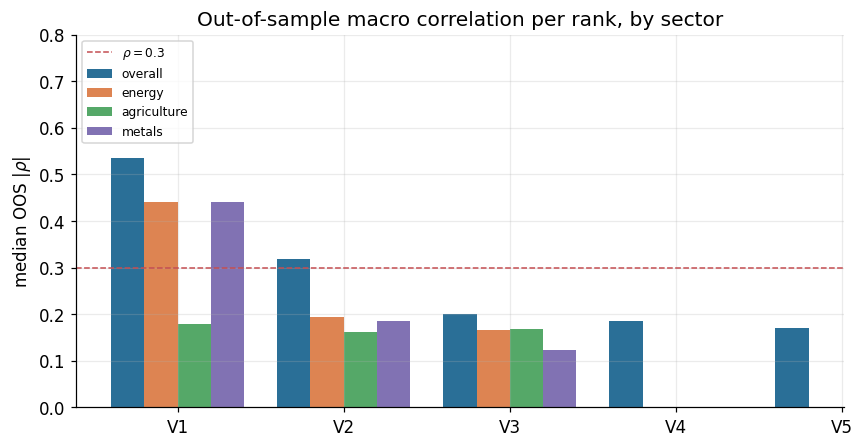

saved -> figures/notebook/sector_oos_rho_by_rank.png
Leading-axis macro fingerprint per sector:


,top_macro
block,
overall,xle(+0.32); inflsw_5y(+0.23); be_5y(+0.23); fx...
energy,xle(+0.17); inflsw_5y(+0.14); be_5y(+0.13); in...
agriculture,gpr(+0.09); mxef(+0.08); hscei(+0.07); fx_audu...
metals,ovx(+0.10); gvz(+0.10); fx_usdclp(+0.09); cny_...


In [6]:
# OOS macro correlation per rank, grouped by block.
sstab = load(f"{SEC}/sector_rank_stability.csv")
max_ranks = int(sstab.groupby("block")["rank"].count().max())
fig, ax = plt.subplots(figsize=(9, 4.4))
width = 0.8 / len(order)
xr = np.arange(max_ranks)
for i, b in enumerate(order):
    d = sstab[sstab["block"] == b].reset_index(drop=True)
    vals = np.full(max_ranks, np.nan); vals[: len(d)] = d["median_rho_oos"].to_numpy()
    ax.bar(xr + i * width, vals, width, label=b, color=BLOCK_C.get(b, "#8C8C8C"))
ax.axhline(0.3, color=BAR_C, ls="--", lw=1, label=r"$\rho=0.3$")
ax.set_xticks(xr + width * (len(order) - 1) / 2)
ax.set_xticklabels([f"V{k+1}" for k in range(max_ranks)])
ax.set_ylim(0, 0.8)
ax.set_ylabel(r"median OOS $|\rho|$")
ax.set_title("Out-of-sample macro correlation per rank, by sector")
ax.legend(fontsize=8)
show_save(fig, "sector_oos_rho_by_rank")

# Leading-axis macro fingerprint per block.
sfp = load(f"{SEC}/sector_macro_fingerprint.csv")
lead_fp = sfp[sfp["rank"] == "V1"][["block", "top_macro"]].set_index("block").reindex(order)
print("Leading-axis macro fingerprint per sector:")
display(lead_fp)


## 4. Robustness — vanilla AE vs β-VAE

Is the surviving macro axis a property of the *data* or an artefact of the vanilla
autoencoder? We re-run the whole rolling engine with a β-VAE (KL-regularised,
disentanglement-prior latents, β=4) and compare the leading-axis stability, both
overall and per sector.


Leading-axis stability reproduces across factor models:


,block,vanilla_|cos|,vanilla_class,beta_|cos|,beta_class
0,overall,0.820,stable,0.711,stable
1,energy,0.778,stable,0.833,stable
2,agriculture,0.381,weak,0.252,weak
3,metals,0.845,stable,0.753,stable


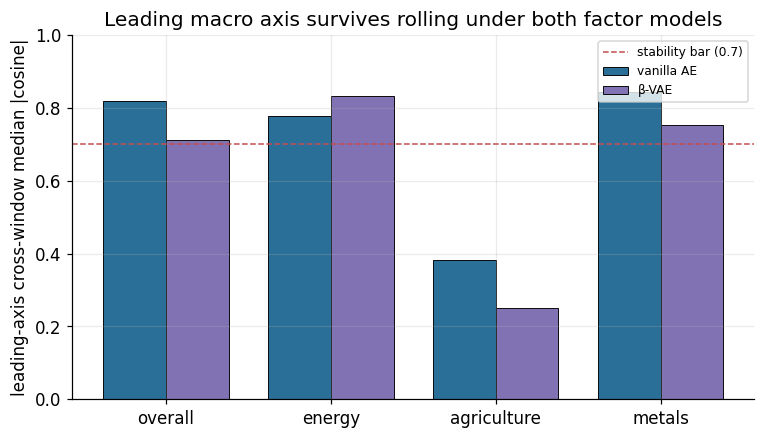

saved -> figures/notebook/model_compare_leading_axis.png


In [7]:
ov, ovb = load(f"{OV}/rank_stability.csv"), load(f"{OVB}/rank_stability.csv")
sv, sb = load(f"{SEC}/sector_summary.csv"), load(f"{SECB}/sector_summary.csv")

compare = pd.DataFrame({
    "block": ["overall"] + [b for b in BLOCK_ORDER if b != "overall" and b in sv["block"].tolist()],
})
def lead_cos(df_ov, df_sec, block):
    if block == "overall":
        return float(df_ov.iloc[0]["median_abs_cos"]), str(df_ov.iloc[0]["stability_class"])
    row = df_sec[df_sec["block"] == block].iloc[0]
    return float(row["lead_median_abs_cos"]), str(row["lead_rank_class"])

rows = []
for b in compare["block"]:
    vcos, vcls = lead_cos(ov, sv, b)
    bcos, bcls = lead_cos(ovb, sb, b)
    rows.append({"block": b, "vanilla_|cos|": vcos, "vanilla_class": vcls,
                 "beta_|cos|": bcos, "beta_class": bcls})
cmp = pd.DataFrame(rows)
print("Leading-axis stability reproduces across factor models:")
display(cmp.round(3))

fig, ax = plt.subplots(figsize=(8, 4.3))
x = np.arange(len(cmp)); w = 0.38
ax.bar(x - w/2, cmp["vanilla_|cos|"], w, label="vanilla AE", color="#2A6F97", edgecolor="black", lw=0.6)
ax.bar(x + w/2, cmp["beta_|cos|"], w, label="β-VAE", color="#8172B3", edgecolor="black", lw=0.6)
ax.axhline(0.7, color=BAR_C, ls="--", lw=1, label="stability bar (0.7)")
ax.set_xticks(x); ax.set_xticklabels(cmp["block"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("leading-axis cross-window median |cosine|")
ax.set_title("Leading macro axis survives rolling under both factor models")
ax.legend(fontsize=8)
show_save(fig, "model_compare_leading_axis")


## 5. Forecasting under rolling — does the null survive too?

Now the harder test: with the factor state re-estimated every window, does the
factor-augmented AR beat AR(1) out-of-sample? Pooled across all non-overlapping
rolling test blocks at h ∈ {1, 5, 21, 63} trading days — overall and per sector.
The predictor uses only the price-derived factor state; macro never enters the
forecast, it only *names* the axes in §2–§4.


Overall panel — pooled OOS forecast accuracy:


,horizon,n_origins,n_nonoverlap,r2_vs_ar1,r2_vs_zero,cw_p,cw_nonoverlap_p,beats_zero
0,1,2617,2617,-0.02653,-0.03513,0.40376,0.40872,False
1,5,2613,523,-0.02606,-0.05850,0.52910,0.47907,False
2,21,2597,124,-0.02452,-0.20905,0.82427,0.76249,False
3,63,2555,41,-0.02351,-1.47970,0.94289,0.25553,False


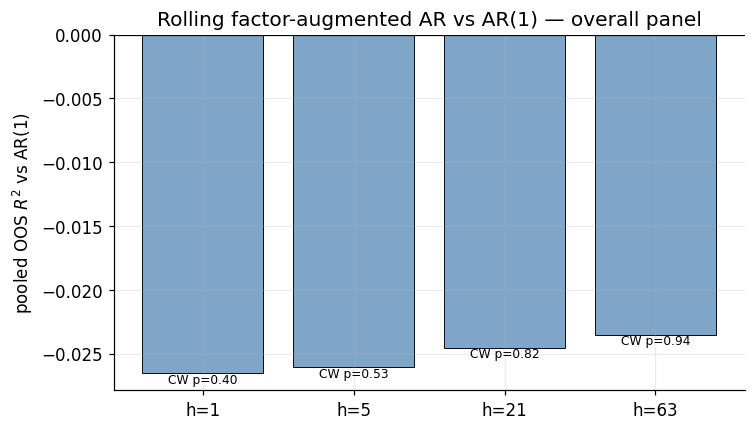

saved -> figures/notebook/forecast_null_overall.png


In [8]:
pool = load(f"{OV}/forecast_accuracy_pooled.csv")
print("Overall panel — pooled OOS forecast accuracy:")
display(pool[["horizon", "n_origins", "n_nonoverlap", "r2_vs_ar1", "r2_vs_zero",
              "cw_p", "cw_nonoverlap_p", "beats_zero"]].round(5))

fig, ax = plt.subplots(figsize=(7.4, 4.2))
x = np.arange(len(pool))
ax.bar(x, pool["r2_vs_ar1"], color="#7FA6C9", edgecolor="black", lw=0.6)
ax.axhline(0, color="black", lw=0.8)
for xi, (_, r) in zip(x, pool.iterrows()):
    ax.annotate(f"CW p={r['cw_p']:.2f}", (xi, r["r2_vs_ar1"]), ha="center",
                va="top" if r["r2_vs_ar1"] < 0 else "bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"h={int(h)}" for h in pool["horizon"]])
ax.set_ylabel(r"pooled OOS $R^2$ vs AR(1)")
ax.set_title("Rolling factor-augmented AR vs AR(1) — overall panel")
show_save(fig, "forecast_null_overall")


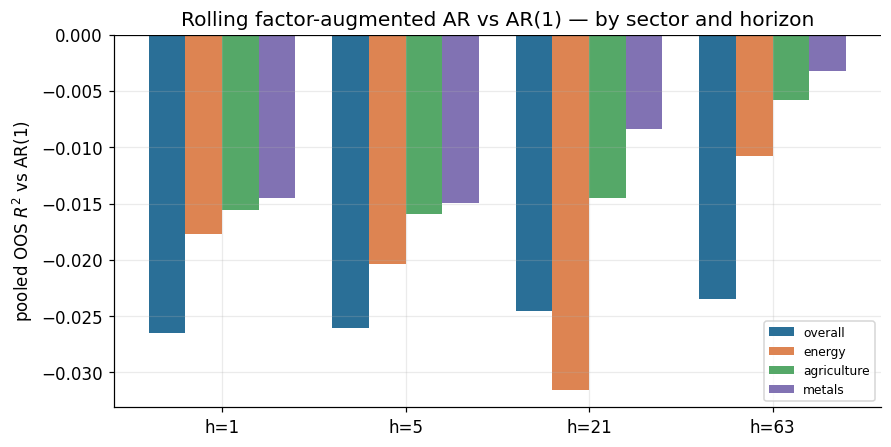

saved -> figures/notebook/forecast_null_by_sector.png
Best (smallest) Clark-West p across horizons, per block:


,min_cw_p
block,
overall,0.404
energy,0.130
agriculture,0.381
metals,0.109



No block beats AR(1) at any horizon (all Clark-West p >= 0.05): the factor state carries no lagged first-moment predictive content, sector-by-sector — consistent with near-efficient daily futures.


In [9]:
# Same test, per sector: is the null uniform across sectors?
spool = load(f"{SEC}/sector_forecast_pooled.csv")
order = [b for b in BLOCK_ORDER if b in spool["block"].tolist()]
horizons = sorted(spool["horizon"].unique())
fig, ax = plt.subplots(figsize=(9, 4.4))
width = 0.8 / len(order)
x = np.arange(len(horizons))
for i, b in enumerate(order):
    d = spool[spool["block"] == b].set_index("horizon").reindex(horizons)
    ax.bar(x + i * width, d["r2_vs_ar1"], width, label=b, color=BLOCK_C.get(b, "#8C8C8C"))
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x + width * (len(order) - 1) / 2)
ax.set_xticklabels([f"h={int(h)}" for h in horizons])
ax.set_ylabel(r"pooled OOS $R^2$ vs AR(1)")
ax.set_title("Rolling factor-augmented AR vs AR(1) — by sector and horizon")
ax.legend(fontsize=8)
show_save(fig, "forecast_null_by_sector")

worst_p = spool.groupby("block")["cw_p"].min().reindex(order)
print("Best (smallest) Clark-West p across horizons, per block:")
display(worst_p.round(3).to_frame("min_cw_p"))
print("\nNo block beats AR(1) at any horizon (all Clark-West p >= 0.05): the "
      "factor state carries no lagged first-moment predictive content, "
      "sector-by-sector — consistent with near-efficient daily futures.")


## 6. Takeaways

1. **The explanation survives rolling (headline).** With the AE *and* the CCA
   basis re-fit on every 252-day window, the leading canonical axis keeps the
   **same macro fingerprint** across all ~125 windows (cross-window median |cos|
   ≈ 0.82 vs a ≈ 0.13 shuffle chance, p < 0.01) and still tracks macro
   out-of-sample in the majority of windows. One dominant
   dollar / inflation / energy-equity axis is **regime-transportable**; the lower
   ranks rotate. It reproduces under the β-VAE (§4).

2. **Sector heterogeneity is real, not an AE artefact.** Running the same rolling
   engine per sector, **energy and metals keep a stable, out-of-sample macro
   axis** under full per-window re-fitting; **agriculture rotates** — the
   idiosyncratic sector. Same ranking under the β-VAE (§3–§4).

3. **The forecast null survives rolling too.** Even with a fully regime-adaptive
   representation, the factor-augmented AR does **not** beat AR(1) at any horizon,
   overall or in any sector (all Clark–West p ≥ 0.05). What survives rolling is
   the *explanation*, not forecast value — coherent with near-efficient daily
   futures. On any daily cross-asset design, mind the clock: US macro closes
   hours after commodity settlements, so naive same-day "lag-1" reads are
   asynchronous-close artefacts (this engine embargoes/aligns accordingly).

**Full reports:** `reports/rolling_forecast_report.md`,
`reports/rolling_forecast_beta_report.md`, `reports/rolling_sectors_report.md`,
`reports/rolling_sectors_beta_report.md`.
